# SOC-50 → 14대분류 재그룹 분류기 학습

## 이 노트북의 목적
세분류를 **최상위 대분류 레벨(14클래스)** 까지 더 완화한다.
50종 → 28그룹 → 14대분류로 이어지는 3단계 비교의 마지막 단계.

## 재그룹 규칙 (모든 대분류를 같은 레벨로 통일)
- **민수 차량 40종 → 4대분류**: Car / Truck / Bus / Construction
- **MSTAR 군용 10종 → type 그대로 10클래스** (군용은 묶지 않음)
- **합계: 4 + 10 = 14클래스**

## 28그룹과의 차이
- Car 5서브 → **Car 1개**, Truck 9서브 → **Truck 1개**, Bus 3서브 → **Bus 1개**
- Construction은 그대로 1개 (로더+롤러)
- 구급차·ECV는 28그룹과 동일하게 Bus(Small_Bus였던 것)에 포함
- → Car만 줄이는 불균형 없이 4대분류를 같은 굵기로 통일

## 준비물 (드라이브 `MyDrive/ATRNet-STAR/`)
- `soc50.tar` (SOC-50 칩), 런타임 → T4 GPU

## 1. 환경 + 데이터 준비

In [ ]:
import torch, os
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
DATA_DIR = "/content/SOC_50classes"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("train 폴더(=50종) 수:", len(os.listdir(TRAIN_DIR)))

Mounted at /content/drive
device: cuda
train 폴더(=50종) 수: 50


## 2. 50종 → 14대분류 매핑 정의

`TYPE2GROUP` 딕셔너리가 **50개 type 폴더명 → 14개 그룹명**을 정의한다.
- 민수 4 + MSTAR 10 = 14
- 폴더명은 SOC-50 데이터의 실제 클래스 폴더명과 정확히 일치해야 함 (오타·공백 주의)

> ⚠ 만약 매핑 누락(폴더명 불일치)이 있으면 아래 셀의 검증에서 에러로 알려준다.

In [ ]:
# ===== 50종 type → 14 대분류 매핑 =====
# 민수 40종 → Car/Truck/Bus/Construction 4대분류, MSTAR 10종은 type 유지
CAR = ["Hawtai_EV160B","Chery_qq3","Chery_Arrizo 5","Buick_Excelle_GT",
       "Great_Wall_Voleex_C50","Hongqi_CA7180A3E","Hongqi_h5",
       "Lincoln_MKC","Mitsubishi_Outlander_2003","Jeep_Patriot",
       "Changfeng_Cheetah_CFA6473C","Chang'an_CS75_Plus","Chevrolet_Blazer_1998"]
TRUCK = ["FAW_Jiabao_T51","Foton_BJ1045V9JB5-54","WAW_Aochi_1800",
         "Dongfeng_Tianjin_DFH2200B","SHACMAN_DeLong_X3000","Dongfeng_Tianjin_KR230",
         "SHACMAN_DeLong_M3000","FAW_J6P","WAW_Aochi_Hongrui","Dongfeng_Duolika",
         "JAC_Junling","Huanghai_N1","Great_Wall_poer","CNHTC_HOWO","Hyundai_HLF25_II"]
BUS = ["Dongfeng_Forthing_Lingzhi","Buick_GL8","Wuling_Rongguang_V","Chang'an_Starlight_4500",
       "JINBEI_SY5033XJH","Lveco_Proud_2009",            # 구급차, ECV (28그룹과 동일하게 Bus)
       "Dongfeng_EQ6608LTV","MAXUS_V80","Yangzi_YZK6590XCA","Yutong_ZK6120HY1"]
CONSTRUCTION = ["SDLG_ZL40F","Changlin_8228-5"]           # 로더, 롤러
MSTAR = ["2S1","BMP2","BRDM_2","BTR_60","BTR70","D7","T62","T72","ZIL131","ZSU_23_4"]

TYPE2GROUP = {}
for t in CAR:          TYPE2GROUP[t]="Car"
for t in TRUCK:        TYPE2GROUP[t]="Truck"
for t in BUS:          TYPE2GROUP[t]="Bus"
for t in CONSTRUCTION: TYPE2GROUP[t]="Construction"
for t in MSTAR:        TYPE2GROUP[t]=t                    # 군용은 type 그대로

# ----- 검증: 디스크 폴더와 매핑 키가 일치하는지 -----
disk_types = set(os.listdir(TRAIN_DIR))
map_types  = set(TYPE2GROUP)
missing = disk_types - map_types
extra   = map_types - disk_types
print("폴더 종류:", len(disk_types), "/ 매핑 종류:", len(map_types))
if missing: print("⚠ 매핑 누락(폴더에 있음):", sorted(missing))
if extra:   print("⚠ 폴더명 불일치(매핑에만 있음):", sorted(extra))
if not missing and not extra: print("✓ 매핑 완전 일치")

GROUPS = sorted(set(TYPE2GROUP.values()))
print(f"\n최종 그룹 수: {len(GROUPS)}")   # 14 기대
print(GROUPS)

폴더 종류: 50 / 매핑 종류: 50
✓ 매핑 완전 일치

최종 그룹 수: 14
['2S1', 'BMP2', 'BRDM_2', 'BTR70', 'BTR_60', 'Bus', 'Car', 'Construction', 'D7', 'T62', 'T72', 'Truck', 'ZIL131', 'ZSU_23_4']


## 3. 라벨 매핑 데이터셋

`ImageFolder`는 폴더명 알파벳순으로 0~49 라벨을 매기는데, 그 라벨을 **14대분류 인덱스로 다시 매핑**한다.
- `GROUP2IDX`: 14대분류 → 0~13 정수 (알파벳순 고정 — 추론 시 동일 순서 필수)
- `remap`: ImageFolder의 50종 라벨 → 14대분류 라벨로 변환하는 타깃 변환

> 폴더를 복사하지 않고 라벨만 바꾸므로, 같은 디스크 데이터로 50종/14대분류 학습을 모두 할 수 있다.

In [ ]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

GROUP2IDX = {g: i for i, g in enumerate(GROUPS)}      # 14대분류 → 0~13
NUM_CLASSES = len(GROUPS)

# 증강 레시피 = 기존 분류기와 동일 (공정 비교)
train_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.RandomErasing(p=0.3),
])
test_transform = T.Compose([
    T.Resize((128, 128)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

def make_remapped(root, transform):
    ds = ImageFolder(root, transform=transform)
    # ImageFolder 라벨(50종 인덱스) → 14대분류 인덱스 변환표
    idx2group = {i: GROUP2IDX[TYPE2GROUP[name]] for i, name in enumerate(ds.classes)}
    # ⚠ 이중 매핑 금지: samples만 변환하고 target_transform은 None
    ds.samples = [(p, idx2group[y]) for p, y in ds.samples]
    ds.targets = [y for _, y in ds.samples]
    ds.imgs = ds.samples            # 일부 버전 호환
    ds.target_transform = None      # 핵심: __getitem__에서 재매핑 안 되도록
    return ds

train_ds = make_remapped(TRAIN_DIR, train_transform)
test_ds  = make_remapped(TEST_DIR,  test_transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
print(f"train {len(train_ds)} / test {len(test_ds)} / 클래스 {NUM_CLASSES}")

# 그룹별 샘플 수 분포 (불균형 확인)
from collections import Counter
cnt = Counter(train_ds.targets)
print("\n그룹별 train 샘플 수:")
for g in GROUPS:
    print(f"  {g:15s}: {cnt[GROUP2IDX[g]]}")

train 18071 / test 17603 / 클래스 14

그룹별 train 샘플 수:
  2S1            : 299
  BMP2           : 698
  BRDM_2         : 298
  BTR70          : 233
  BTR_60         : 256
  Bus            : 3600
  Car            : 4680
  Construction   : 720
  D7             : 299
  T62            : 299
  T72            : 691
  Truck          : 5400
  ZIL131         : 299
  ZSU_23_4       : 299


## 4. 모델 — ConvNeXt-Tiny (14대분류 출력)

기존 ConvNeXt 분류기와 동일 구조/레시피, **출력층만 14로** 교체.
- ImageNet 사전학습 → classifier[2]만 14대분류로
- label smoothing 0.1, AdamW 1e-4, cosine 30에폭

> 다른 백본(ResNet18/SARATR-X)으로 바꾸려면 이 셀만 교체.

In [ ]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

MODEL_NAME = "convnext_soc14"
EPOCHS, LR = 30, 1e-4

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

CKPT_PATH = f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_ckpt.pth"
os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
print(f"{MODEL_NAME} / 출력 {NUM_CLASSES}클래스")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 154MB/s]


convnext_soc14 / 출력 14클래스


## 5. 학습 루프 (체크포인트 이어학습)

In [ ]:
import time
start_epoch, history = 0, []
if os.path.exists(CKPT_PATH):
    c = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(c["model"]); optimizer.load_state_dict(c["optimizer"])
    scheduler.load_state_dict(c["scheduler"])
    start_epoch, history = c["epoch"] + 1, c["history"]
    print(f"체크포인트 발견 → 에폭 {start_epoch+1}부터 재개")

for epoch in range(start_epoch, EPOCHS):
    model.train(); tl = correct = n = 0
    t0 = time.time()
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        tl += loss.item()*len(y); correct += (out.argmax(1)==y).sum().item(); n += len(y)
    scheduler.step()
    history.append({"epoch": epoch, "train_loss": tl/n, "train_acc": correct/n})
    print(f"Epoch {epoch+1}/{EPOCHS}  loss {tl/n:.3f}  train_acc {correct/n:.3f}  ({time.time()-t0:.0f}s)")
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "epoch": epoch, "history": history}, CKPT_PATH)
print("학습 완료")

Epoch 1/30  loss 1.395  train_acc 0.583  (106s)
Epoch 2/30  loss 1.063  train_acc 0.750  (99s)
Epoch 3/30  loss 0.961  train_acc 0.806  (102s)
Epoch 4/30  loss 0.900  train_acc 0.833  (103s)
Epoch 5/30  loss 0.856  train_acc 0.857  (104s)
Epoch 6/30  loss 0.818  train_acc 0.873  (104s)
Epoch 7/30  loss 0.789  train_acc 0.888  (104s)
Epoch 8/30  loss 0.757  train_acc 0.904  (104s)
Epoch 9/30  loss 0.743  train_acc 0.910  (104s)
Epoch 10/30  loss 0.726  train_acc 0.920  (104s)
Epoch 11/30  loss 0.709  train_acc 0.928  (106s)
Epoch 12/30  loss 0.702  train_acc 0.930  (105s)
Epoch 13/30  loss 0.686  train_acc 0.938  (105s)
Epoch 14/30  loss 0.674  train_acc 0.944  (104s)
Epoch 15/30  loss 0.671  train_acc 0.943  (104s)
Epoch 16/30  loss 0.661  train_acc 0.948  (104s)
Epoch 17/30  loss 0.661  train_acc 0.950  (104s)
Epoch 18/30  loss 0.646  train_acc 0.955  (104s)
Epoch 19/30  loss 0.641  train_acc 0.958  (104s)
Epoch 20/30  loss 0.643  train_acc 0.956  (104s)
Epoch 21/30  loss 0.637  train

## 6. 평가 + 저장

- 전체 정확도(OA) 측정
- **혼동행렬**로 어느 그룹끼리 헷갈리는지 확인 (14대분류라 50종보다 읽기 쉬움)
- 추론용 가중치 `*_final.pth` + 클래스 순서 json 저장 (파이프라인에서 사용)

In [ ]:
import json, numpy as np
model.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device, non_blocking=True))
        y_pred.extend(out.argmax(1).cpu().tolist()); y_true.extend(y.tolist())
y_true, y_pred = np.array(y_true), np.array(y_pred)
oa = float((y_true==y_pred).mean())
print(f"Overall Accuracy (14클래스): {oa*100:.2f}%")
print("(참고: 50종 87.75% / 28그룹 90.86% — 더 줄여 더 높게 기대)")

per_class = {g: float((y_pred[y_true==i]==i).mean()) for i,g in enumerate(GROUPS) if (y_true==i).sum()>0}
print("\n그룹별 정확도 (낮은 순 Top10 — 어려운 그룹):")
for g,a in sorted(per_class.items(), key=lambda x:x[1])[:10]:
    print(f"  {g:15s}: {a*100:.1f}%")

# 가중치 + 클래스 순서 저장
torch.save(model.state_dict(), f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_final.pth")
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
with open(f"{SAVE_DIR}/results/{MODEL_NAME}.json","w") as f:
    json.dump({"model": MODEL_NAME, "num_classes": NUM_CLASSES, "classes": GROUPS,
               "type2group": TYPE2GROUP, "overall_acc": oa,
               "per_class_acc": per_class, "history": history}, f, ensure_ascii=False)
print(f"\n저장: checkpoints/{MODEL_NAME}_final.pth + results/{MODEL_NAME}.json")

Overall Accuracy (14클래스): 94.54%
(참고: 50종 87.75% / 28그룹 90.86% — 더 줄여 더 높게 기대)

그룹별 정확도 (낮은 순 Top10 — 어려운 그룹):
  Bus            : 89.0%
  Construction   : 90.3%
  Car            : 94.4%
  Truck          : 96.0%
  BTR_60         : 98.5%
  ZIL131         : 98.9%
  2S1            : 99.3%
  BMP2           : 99.5%
  BTR70          : 99.5%
  T62            : 99.6%

저장: checkpoints/convnext_soc14_final.pth + results/convnext_soc14.json


## 7. 혼동행렬 시각화

/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()
/tmp/ipykernel_1631/270998983.py:10: UserWarning: Glyph 46041 (\N{HANGUL 

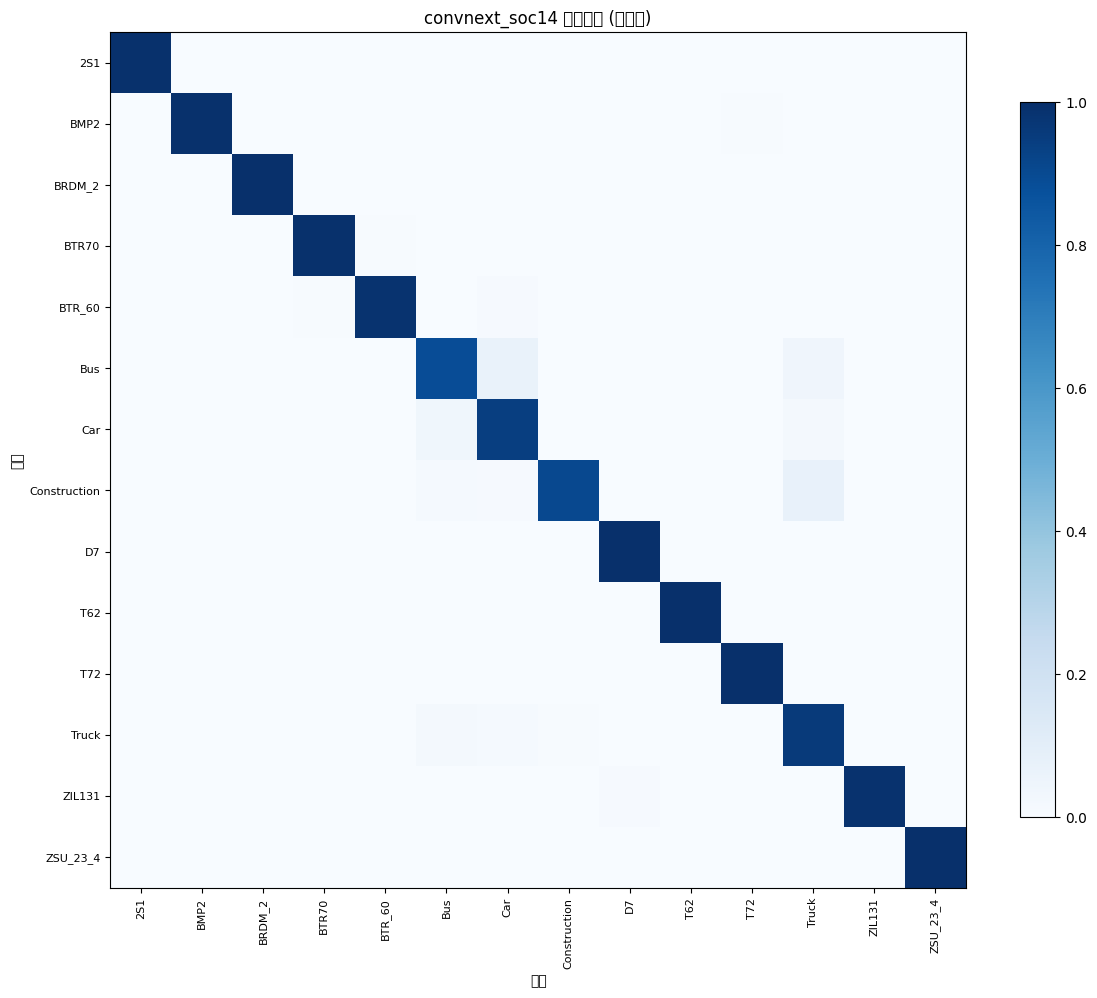

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(GROUPS, rotation=90, fontsize=8)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(GROUPS, fontsize=8)
ax.set_xlabel("예측"); ax.set_ylabel("정답"); ax.set_title(f"{MODEL_NAME} 혼동행렬 (정규화)")
fig.colorbar(im, shrink=0.7); plt.tight_layout(); plt.show()

## 다음 단계 — 파이프라인에서 사용하기

`pipeline/soc14/dom48_convnext.ipynb`의 분류기 로드 셀에서:
1. 모델을 `convnext_tiny()` + `classifier[2] = nn.Linear(..., 14)`로 만들고
2. `checkpoints/convnext_soc14_final.pth` 로드
3. **클래스 순서**는 `results/convnext_soc14.json`의 `classes`(=GROUPS) 사용

⚠ **GT 라벨도 14대분류으로 변환** 필요: DOM XML의 `type`을 `TYPE2GROUP`으로 매핑해서 채점해야
분류기 출력(14대분류)과 정답이 같은 체계가 됨. (50종 GT를 그대로 쓰면 전부 불일치)

### 비교 포인트 (보고서)
- 50종 87.75% vs 14대분류 OA → 세분화 완화의 효과
- 단, **fine-grained 식별 능력은 포기**하는 트레이드오프 (예: 같은 SUV 3종을 한 클래스로)
  → 군 정찰 목적상 "차종 대분류"로 충분한지 vs "정확한 기종 식별"이 필요한지에 따라 선택